In [1]:
# ==========================================
# ENVIRONMENT SETUP (SOTA ROOT ANCHOR)
# ==========================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

def find_project_root(markers=(".git", "pyproject.toml", "src")):
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if any((parent / marker).exists() for marker in markers):
            return parent
    raise RuntimeError("Project root not found.")

project_root = str(find_project_root())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
# ==========================================
# IMPORTS
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
from experiments.scripts.EXP_012_MP_SHRINKAGE_DISTORTION_ALPHA_SWEEP import exp_012_mp_shrinkage_distortion_alpha_sweep

In [3]:
# ==========================================
# CONFIGURATION
# ==========================================
CONFIG = {
    "n": 400,
    "p": 200,
    "k": 3,
    "M": 50,  # Monte Carlo Iterations per Alpha
    "B": 100, # Bootstrap Resamples
    "seed": 42
}

In [4]:
# ==========================================
# RUN EXPERIMENT
# ==========================================
print("Running Shrinkage Distortion Sweep (Parallelized)...")
output = exp_012_mp_shrinkage_distortion_alpha_sweep(**CONFIG)

results = output["results"]
meta = output["meta"]

Running Shrinkage Distortion Sweep (Parallelized)...


Sweeping Factor Strength (Alpha): 100%|██████████| 10/10 [05:04<00:00, 30.49s/it]


In [5]:
# ==========================================
# METADATA
# ==========================================
print("=== META ===")
for k, v in meta.items():
    print(f"{k}: {v}")

=== META ===
n: 400
p: 200
true_k: 3
M: 50
B: 100
seed: 42
execution_time_minutes: 5.08
model_version: 0.1.0


In [8]:
# ==========================================
# DIAGNOSTICS
# ==========================================
print("\n=== DISTORTION DATAFRAME ===")
df = pd.DataFrame({
    "Alpha": results["alphas"],
    "Pearson (k)": results["pearson_mean"],
    "Pearson SE": results["pearson_std"],
    "Ledoit-Wolf (k)": results["lw_mean"],
    "Ledoit-Wolf SE": results["lw_std"]
})
display(df)


=== DISTORTION DATAFRAME ===


,Alpha,Pearson (k),Pearson SE,Ledoit-Wolf (k),Ledoit-Wolf SE
0,1.0,1.26,0.52192,25.24,16.195753
1,2.0,3.00,0.00000,74.84,1.332066
2,3.0,3.00,0.00000,72.98,0.882950
3,4.0,3.00,0.00000,67.20,1.000000
4,5.0,3.00,0.00000,60.12,1.070327
5,6.0,3.00,0.00000,52.74,1.245953
6,7.0,3.00,0.00000,45.82,1.437915
7,8.0,3.00,0.00000,38.94,1.567291
8,9.0,3.00,0.00000,33.20,1.587451
9,10.0,3.00,0.00000,27.56,1.698941


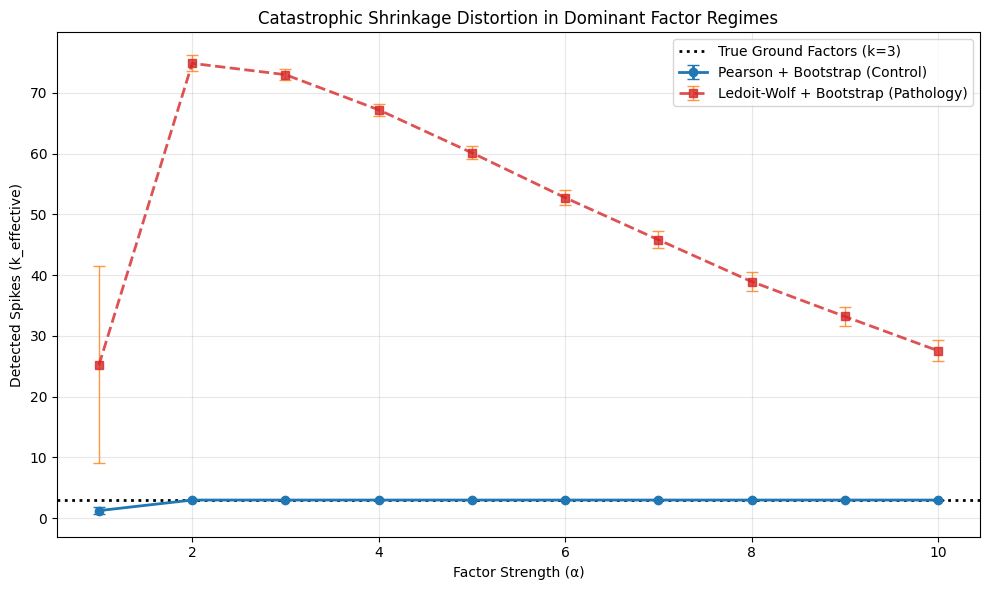

In [9]:
# ==========================================
# VISUALIZATION (RULE 5.2)
# ==========================================
plt.figure(figsize=(10, 6))

alphas = results["alphas"]

plt.errorbar(alphas, results["pearson_mean"], yerr=results["pearson_std"], 
             marker="o", linewidth=2, capsize=4, label="Pearson + Bootstrap (Control)", color="tab:blue")

plt.errorbar(alphas, results["lw_mean"], yerr=results["lw_std"], 
             marker="s", linewidth=2, linestyle="--", capsize=4, label="Ledoit-Wolf + Bootstrap (Pathology)", color="tab:red",
             ecolor='tab:orange', elinewidth=1., capthick=1., alpha=0.8)

plt.axhline(meta["true_k"], color="black", linestyle=":", linewidth=2, label=f"True Ground Factors (k={meta['true_k']})")

plt.xlabel("Factor Strength (α)")
plt.ylabel("Detected Spikes (k_effective)")
plt.title("Catastrophic Shrinkage Distortion in Dominant Factor Regimes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

1. **Theoretical Alignment (The Shrinkage Pathology):** Standard linear regularization (Ledoit-Wolf) fundamentally assumes that extreme deviations in sample eigenvalues are driven by estimation error, shrinking them toward the grand mean. The empirical data proves this is catastrophic when massive structural factors are present. Classical Pearson covariance perfectly isolates the true signal ($k=3$, $SE=0$) once the Baik-Ben Arous-Péché threshold is crossed ($\alpha \ge 2.0$). Ledoit-Wolf, however, misinterprets the true variance of these factors as massive error, aggressively distorting the spectral bulk and destroying the assumptions of Random Matrix Theory.

2. **Finite-Sample Mechanics (Non-Monotonic Hallucination):** The pathology manifests in three severe stages. At the BBP boundary ($\alpha=1.0$), the LW estimator suffers extreme instability ($SE \approx 16.2$) as signal and noise mix. As the true factors violently detach ($\alpha=2.0$), the shrinkage deformation peaks, forcing the Bootstrap to hallucinate $\approx 75$ false positive spikes. Finally, as the signal becomes overwhelmingly dominant ($\alpha \to 10.0$), the shrinkage intensity parameter ($\delta$) saturates. The false spikes decline linearly but remain statistically poisoned, reporting $\approx 27$ factors instead of the ground truth of $3$.

3. **Pipeline Justification (Defactored Shrinkage Mandate):** This experiment dictates an absolute architectural rule for high-dimensional inference in economics and finance. You cannot apply standard covariance regularization to raw matrices possessing a high Signal-to-Noise Ratio. The framework must enforce a two-stage "Defactored Shrinkage" pipeline: first, extract the $k$ principal factors using Pearson + Bootstrap; second, apply Ledoit-Wolf regularization exclusively to the structurally clean residual matrix.